# <b>Formulating the Hypothesis</b>

I hypothesize that:

- More Popular the movie, More people hype the movie to make others watch the movie, which increases vote count.

- Higher budgets lead to higher revenues and greater popularity.

- Movies with larger casts and longer runtimes tend to get better audience ratings.

# <b>Importing Libraries</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json

# <b>Data importing</b>

In [2]:
df1 = pd.read_csv("tmdb_5000_movies.csv")
df2 = pd.read_csv("tmdb_5000_credits.csv")

# <b>Data Pre-processing</b>

##  Merging dataset
Merging has been done based on the primary key "id" from Movies dataset and "movie_id" from Credits dataset. Inner join has been used to prevent null values on ids. and there are 4803 rows and 24 columns initially after merging the two data set into one dataset.

In [3]:
# Merge on 'id' column
merged_df = pd.merge(df1, df2, left_on="id", right_on="movie_id", how="inner")

In [4]:
merged_df.shape

(4803, 24)

## Cleaning the attribute entry - "genre"
The column "genre" describes which genre the movie belongs to, there can be mutiple genres for the same movie. We maynot require them all for the processing, we can consider only the top priority genre of the movie, which is in the first of the list. We also consider secondary and tertiary genres as well. Here the genres are given in JSON format. So extracting has been done to attributes as primary genre, secondary genre and tertiary genre from the the JSON string.

In [5]:
def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        names = [g["name"] for g in genres if "name" in g]
        while len(names) < 3:
            names.append(None)
        return names[:3]
    except Exception:
        return [None, None, None]

In [6]:

merged_df[["primary_genre", "secondary_genre", "tertiary_genre"]] = merged_df["genres"].apply(extract_genres).apply(pd.Series)

In [7]:
merged_df = merged_df.drop(columns=["genres"])

## Taking only the year from date data
As we are dealing with movie dataset, its highly unlikely that we might need the exact date of release, we will be bothered about the year of release of the movie, so we are deriving the year from the actual date of release of the movie.

In [8]:
merged_df["release_year"] = merged_df["release_date"].astype(str).str[:4]

In [9]:
merged_df = merged_df.drop(columns=["release_date"])

## Cleaning the attribute entry - "cast"
The column "cast" has the people who were involved the movie and appeared in the movie as an actor, there will be more than one cast for the same movie. We maynot consider them all for the processing, we can consider only the top lead actors of the movie, which is in the ascending fashion of the list from the the JSON string. We might need the data of Number of cast in a movie, that is also extrated as well.

In [10]:
def extract_leads(cast_str, top_n=3):
    try:
        cast = ast.literal_eval(cast_str)
        names = [c["name"] for c in sorted(cast, key=lambda x: x.get("order", 999))[:top_n]]
        while len(names) < top_n:
            names.append(None)
        return names
    except Exception:
        return [None] * top_n

In [11]:

merged_df[["lead_actor_1", "lead_actor_2", "lead_actor_3"]] = (
    merged_df["cast"].apply(extract_leads).apply(pd.Series)
)

In [12]:
def count_cast(cast_str):
    try:
        return len(ast.literal_eval(cast_str))
    except Exception:
        return 0

In [13]:

merged_df["cast_count"] = merged_df["cast"].apply(count_cast)

In [14]:
merged_df["cast_count"]

0        83
1        34
2        83
3       158
4        27
       ... 
4798      7
4799      5
4800      7
4801      5
4802      8
Name: cast_count, Length: 4803, dtype: int64

In [15]:
merged_df = merged_df.drop(columns=["cast"])

## Removing the unwanted Columns
Due to merging of the data there were some duplicate columns of the primay key "id". And the data analyis for my hypothesis, we dont require columns such as HOMEPAGE or OVERVIEW

In [16]:
merged_df= merged_df.drop(columns=["homepage", "overview", "title_y", "title_x", "movie_id"])

## Cleaning the attribute entry - "production_countries"
The column "production_countries" has the contries where the movie were produced, there will be more than one production country for the same movie. We maynot consider them all for the processing, we can consider only the primary country, which is the first country in the ascending fashion of the list from the the JSON string. We might need the data of Number of countries in a movie, that is also extrated as well.

In [17]:

def extract_country_info(country_str):
    try:
        countries = ast.literal_eval(country_str)
        primary = countries[0]["name"] if countries else None
        count = int(len(countries))
        return pd.Series([primary, count])
    except Exception:
        return pd.Series([None, 0])

merged_df[["primary_country", "num_countries"]] = (
    merged_df["production_countries"].apply(extract_country_info)
)

In [18]:
merged_df["num_countries"] = merged_df["num_countries"].astype("Int64")

In [19]:
merged_df = merged_df.drop(columns=["production_countries"])

## Cleaning the attribute entry - "spoken_languages"
The column "spoken_languages" consitutes of the languages used in the movie, there will be more than one language spoken in the same movie. We maynot consider them all for the processing, we can consider only the primary language, which is the first language in the ascending fashion of the list from the the JSON string. We might need the data of Number of language in a movie, that is also extrated as well.

In [20]:
def extract_languages_iso(lang_str):
    try:
        langs = ast.literal_eval(lang_str)
        primary = langs[0]["iso_639_1"] if langs else None
        count = len(langs)
        return pd.Series([primary, count])
    except Exception:
        return pd.Series([None, 0])

merged_df[["primary_language", "num_languages"]] = (
    merged_df["spoken_languages"].apply(extract_languages_iso)
)

In [21]:

merged_df["num_languages"] = merged_df["num_languages"].astype("Int64")


In [22]:
merged_df = merged_df.drop(columns=["spoken_languages"])

In [23]:
# merged_df.to_csv("movies_cleaned.csv", index=False)

## Delete all the unreleased movie rows
We do not need the movie which have not been released yet, since there is no actual data of the revenue after the release of the movie.

In [24]:
merged_df = merged_df[merged_df["status"] == "Released"].copy()

In [25]:
merged_df = merged_df.drop(columns=["status"])

In [26]:
merged_df.shape

(4795, 25)

## Removing all the null values of budget and revenue
Since, Budget and revenue are important attributes showcasing the worth of the movie, we cant fill the blank spaces with Mean values, there is no point in having them, so we can remove them. And even after removing, we stll had significant portion of the data left. so removing all the null values of budget and revenue is very much required.

In [27]:
no_null_merged_df = merged_df[(merged_df["budget"] != 0) & (merged_df["revenue"] != 0)].copy()

In [28]:
no_null_merged_df.shape

(3228, 25)

## Cleaning the attribute entry - "crew"
The column "crew" has the non-actors who were involved in production of the movie, there will be many people involved in the production of the movie. We maynot consider them all for the processing, we need only the director, which we are concerned about, which is available in the JSON string.

In [29]:
def get_director(crew_str):
    try:
        crew_list = json.loads(crew_str)
        for member in crew_list:
            if member.get("job") == "Director":
                return member.get("name")
    except:
        return None
    return None

In [30]:
no_null_merged_df["director"] = no_null_merged_df["crew"].apply(get_director)

In [31]:
no_null_merged_df = no_null_merged_df.drop(columns=["crew"])

In [32]:

print(no_null_merged_df[["original_title", "director"]].head(10))


                             original_title           director
0                                    Avatar      James Cameron
1  Pirates of the Caribbean: At World's End     Gore Verbinski
2                                   Spectre         Sam Mendes
3                     The Dark Knight Rises  Christopher Nolan
4                               John Carter     Andrew Stanton
5                              Spider-Man 3          Sam Raimi
6                                   Tangled       Byron Howard
7                   Avengers: Age of Ultron        Joss Whedon
8    Harry Potter and the Half-Blood Prince        David Yates
9        Batman v Superman: Dawn of Justice        Zack Snyder


# <b>Data Viz</b>

### 1. Distribution of success

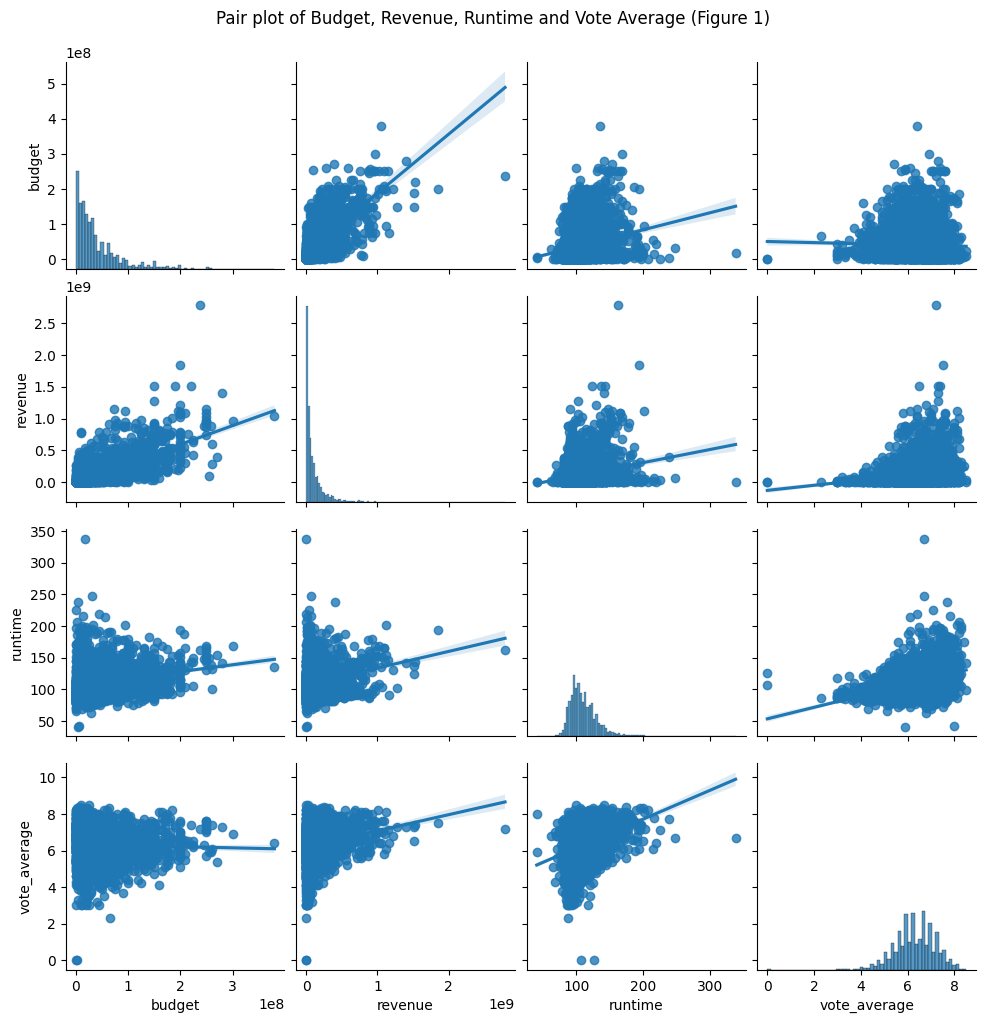

In [33]:
g = sns.pairplot(no_null_merged_df[['budget', 'revenue', 'runtime' , 'vote_average']], kind='reg')
g.fig.suptitle("Pair plot of Budget, Revenue, Runtime and Vote Average (Figure 1)", y=1.02)
plt.show()

This visualization provides an overview of how budget, revenue, runtime, and average ratings relate to one another. We observe a clear positive correlation between budget and revenue, suggesting that higher investment often leads to higher box-office success. However, the relationship between budget and ratings appears weak, implying that spending more money does not guarantee better audience reception.

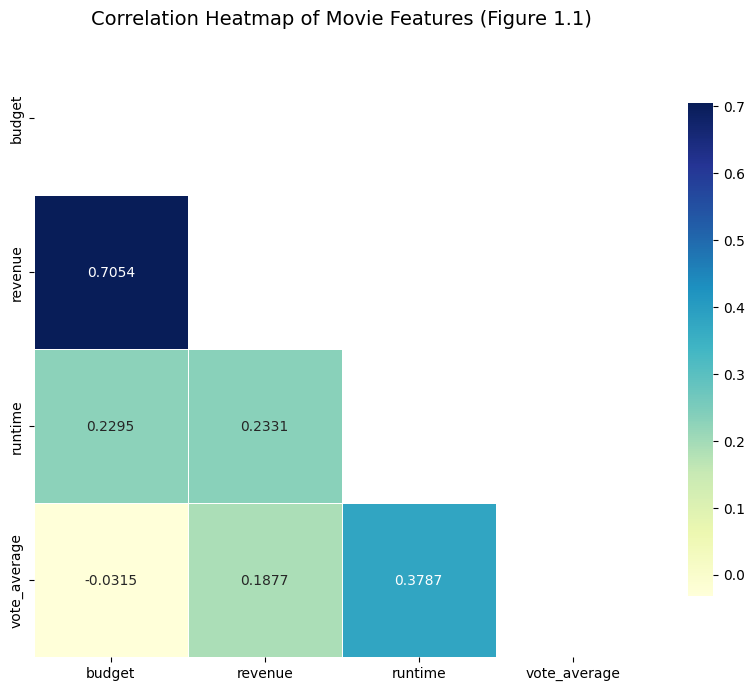

In [34]:
corr = no_null_merged_df[['budget', 'revenue', 'runtime' , 'vote_average']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".4f", cmap="YlGnBu",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap of Movie Features (Figure 1.1)", fontsize=14, pad=12)
plt.show()

From Figure 1 we can see the correlation that exist between budget', 'revenue', 'runtime' and 'vote_average' via pair wise Scatter Plot, there is an obvious correlation between revenue and budget as per the hypothesis, which can be verified in Figure 1.1 other than that, we dont see any significant correlation between any other pair.

### 2. Time-series Analysis

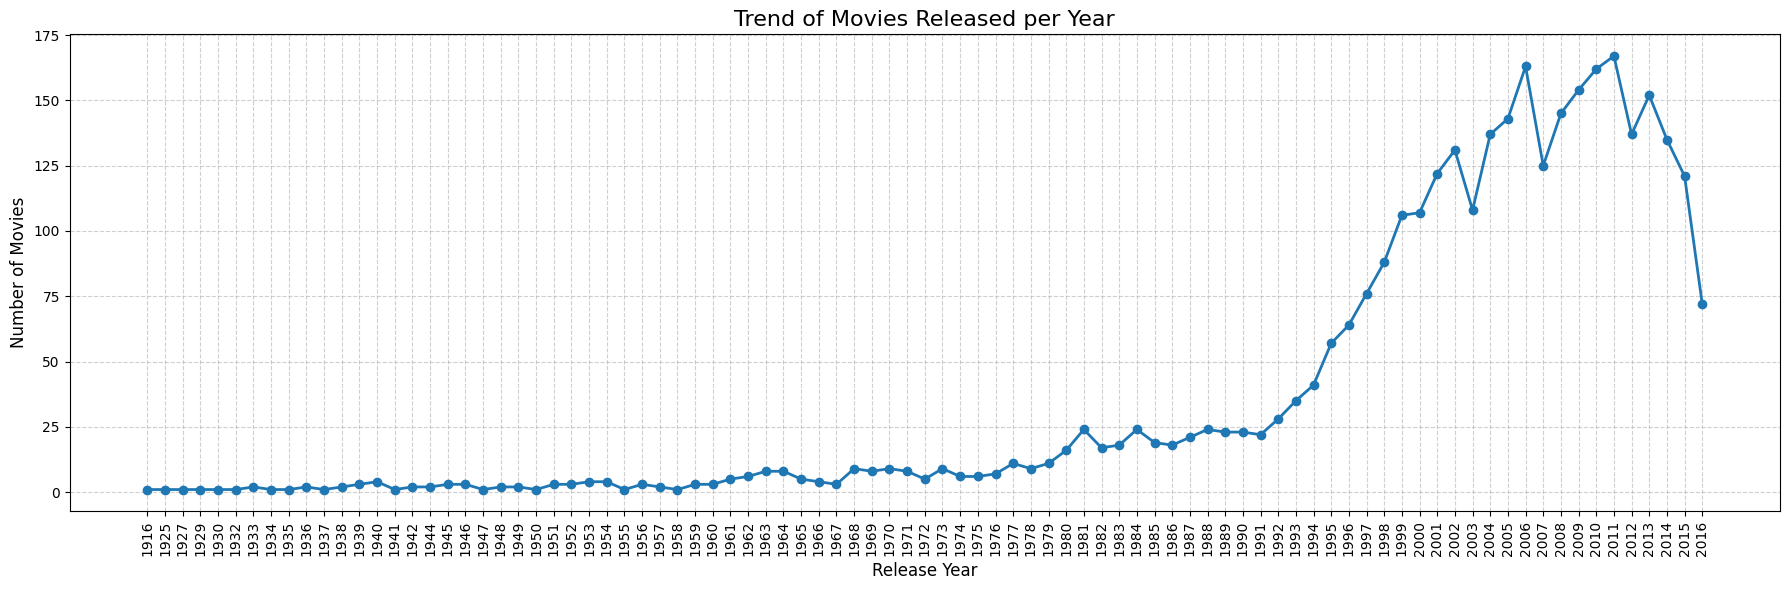

In [35]:
movies_per_year = no_null_merged_df.groupby('release_year').size()

# Plot
plt.figure(figsize=(18,6))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o', linewidth=2)
plt.title("Trend of Movies Released per Year", fontsize=16)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The line plot shows the number of movies released each year. We notice a sharp growth in movie production after the 2000s, reflecting the industry’s expansion and global reach. This increase also highlights greater competition in recent years, which may influence what drives a movie’s success.

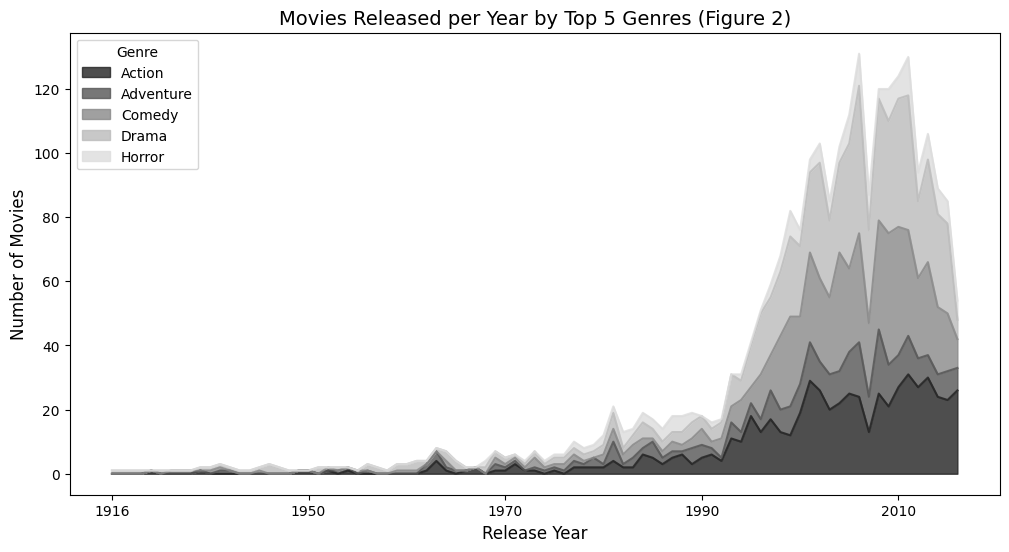

In [36]:
top5_genres = no_null_merged_df["primary_genre"].value_counts().head(5).index

genre_year = (
    no_null_merged_df[no_null_merged_df["primary_genre"].isin(top5_genres)]
    .groupby(["release_year", "primary_genre"])
    .size()
    .unstack(fill_value=0)
)

custom_colors = ['#222222', '#555555', '#888888', '#BBBBBB', '#DDDDDD']

genre_year.plot.area(
    figsize=(12, 6),
    alpha=0.8,
    color=custom_colors
)
plt.title("Movies Released per Year by Top 5 Genres (Figure 2)", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.legend(title="Genre")
plt.show()


We can clearly see to that, Action is the most prefered genre of almost all the time, next to adventure. Order of ranking didnt change much overr the time as well, so it says that directors alomost always preferebly make action films over any other genre, next to drama.

### 3. Revenue & Ratings Breakdown:

/tmp/ipykernel_6931/25168984.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="director", y="vote_average", data=df_top5_directors, palette="colorblind")


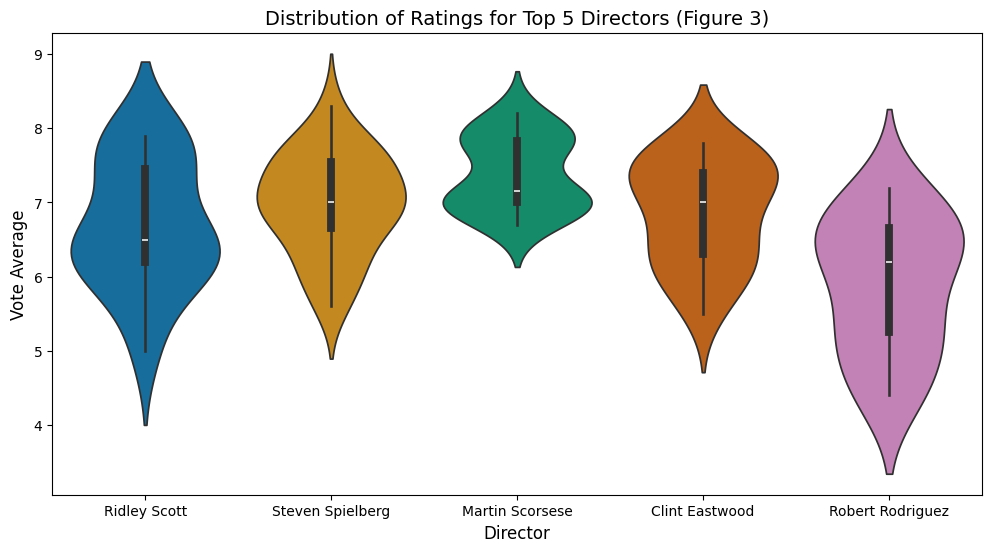

In [49]:
top5_directors = no_null_merged_df["director"].value_counts().head(5).index
df_top5_directors = no_null_merged_df[no_null_merged_df["director"].isin(top5_directors)]

plt.figure(figsize=(12,6))
sns.violinplot(x="director", y="vote_average", data=df_top5_directors, palette="colorblind")

plt.title("Distribution of Ratings for Top 5 Directors (Figure 3)", fontsize=14)
plt.xlabel("Director", fontsize=12)
plt.ylabel("Vote Average", fontsize=12)
plt.show()

The violin plot compares the distribution of audience ratings for movies directed by the five most prolific directors. While some directors show consistent performance with higher median ratings, others demonstrate wide variation, suggesting uneven reception across their films. From the figure (Figure 3), we can also say that Martin Scorsese had been a best director since he has no ratings below 6. Also Steven Spielberg has recieved the top most ratings than any other directors, but only a few times.

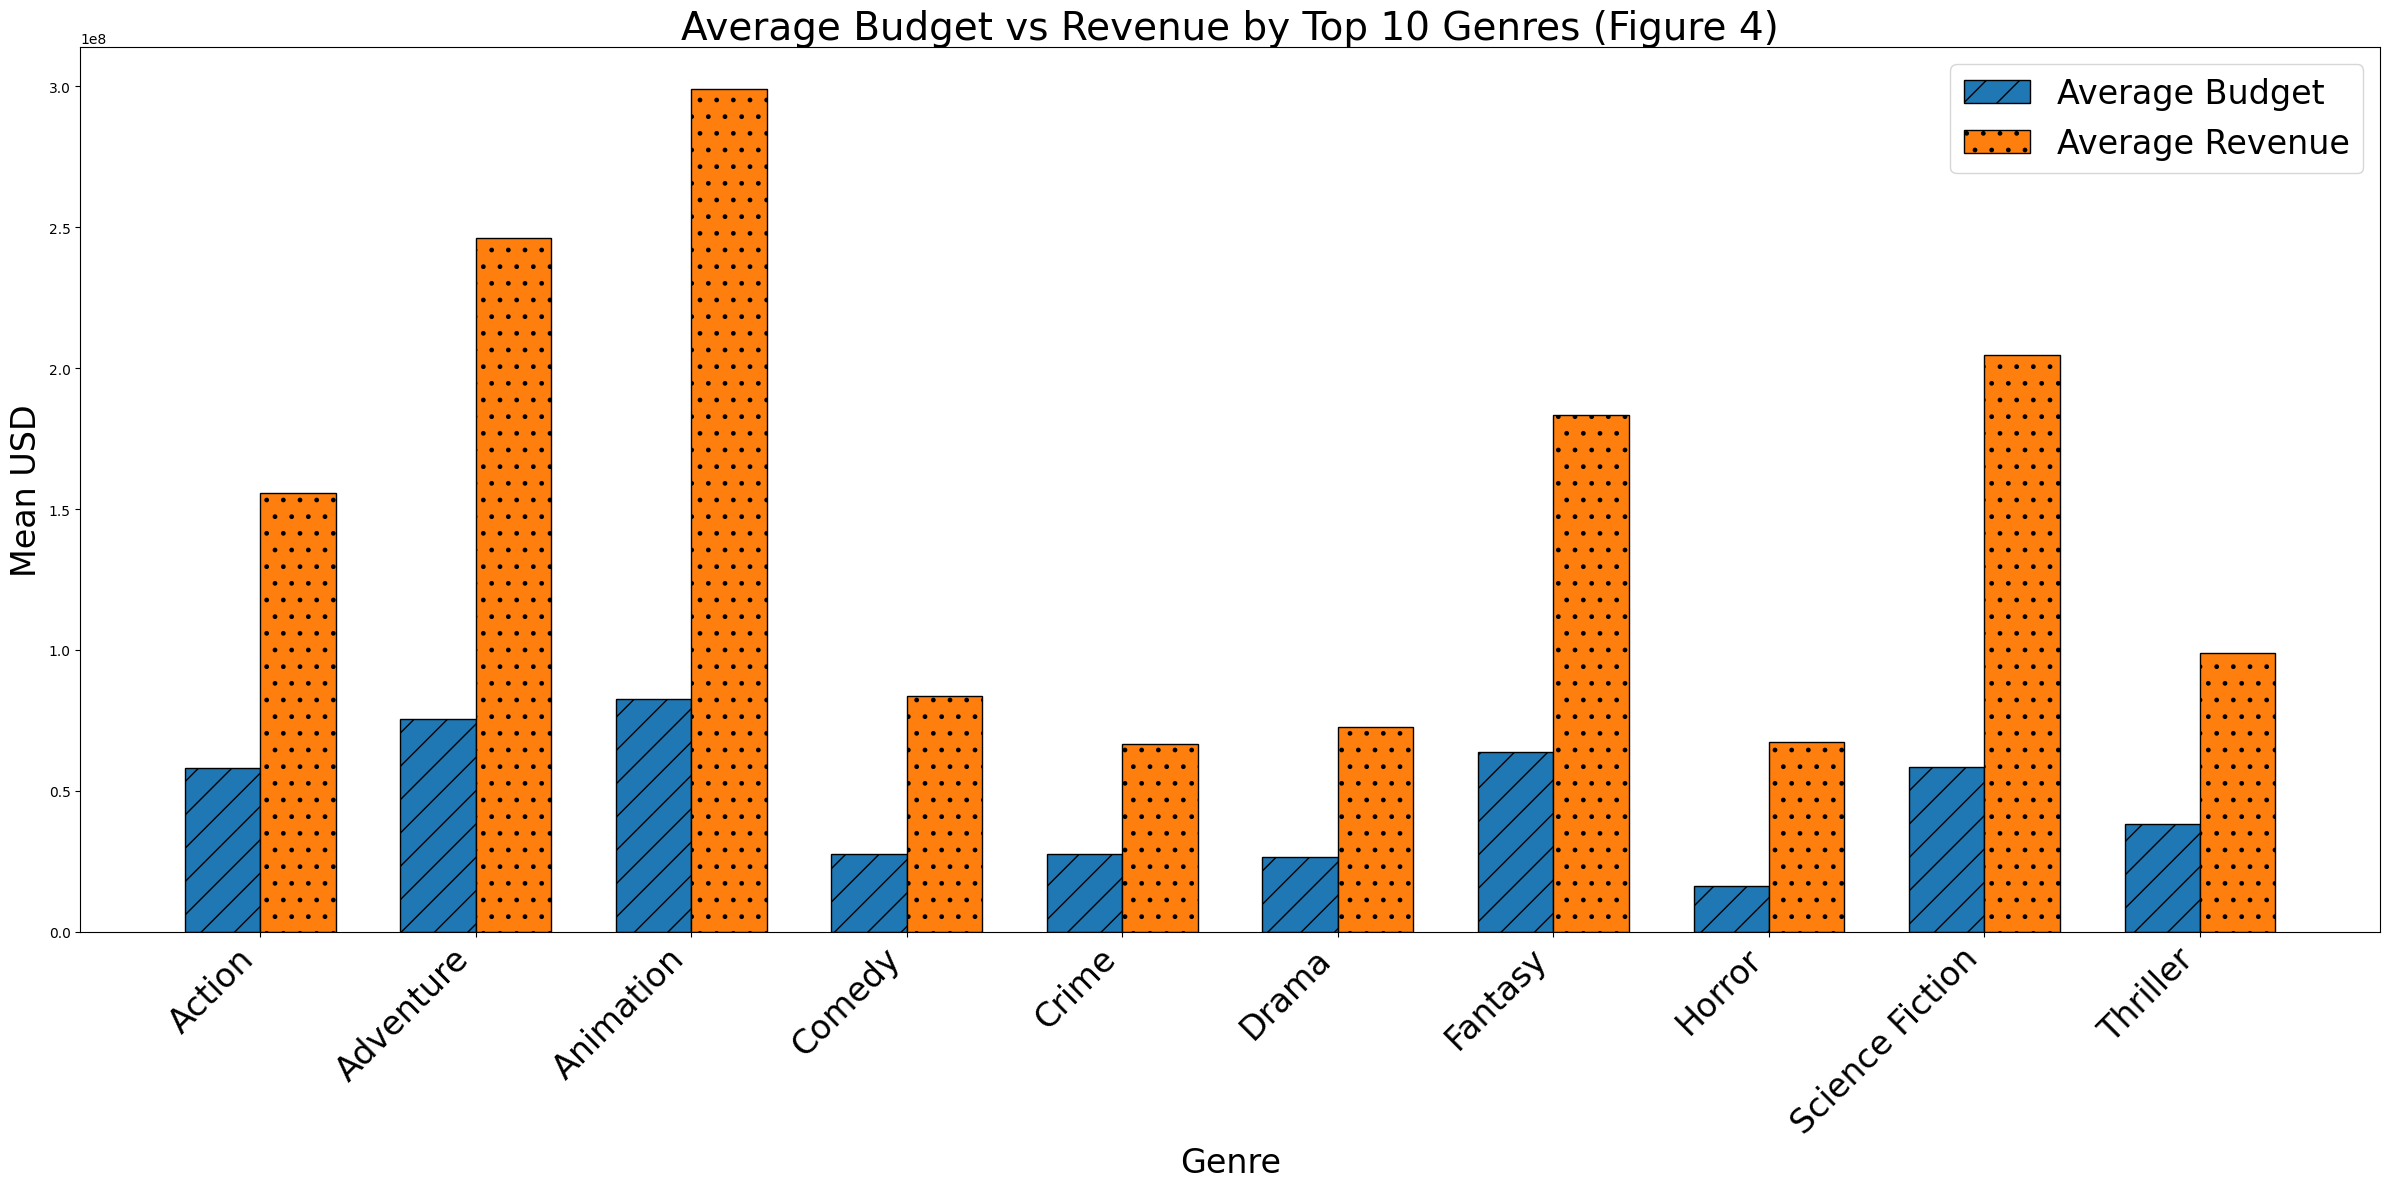

In [38]:
top10_genres = no_null_merged_df["primary_genre"].value_counts().head(10).index

genre_stats = (
    no_null_merged_df[no_null_merged_df["primary_genre"].isin(top10_genres)]
    .groupby("primary_genre")[["budget", "revenue"]]
    .mean()
)

# Plot side-by-side bars
x = np.arange(len(genre_stats))
width = 0.35


hatch_patterns = ['/', '.']  # Budget bars = '/', Revenue bars = '\'

plt.figure(figsize=(24,12))
bars1 = plt.bar(
    x - width/2, 
    genre_stats["budget"], 
    width, 
    label="Average Budget", 
    hatch=hatch_patterns[0], 
    edgecolor='k'
)
bars2 = plt.bar(
    x + width/2, 
    genre_stats["revenue"], 
    width, 
    label="Average Revenue", 
    hatch=hatch_patterns[1], 
    edgecolor='k'
)

plt.xticks(x, genre_stats.index, rotation=45, ha="right", fontsize=24)
plt.title("Average Budget vs Revenue by Top 10 Genres (Figure 4)", fontsize=28)
plt.xlabel("Genre", fontsize=24)
plt.ylabel("Mean USD", fontsize=24)
plt.legend(fontsize=24)
plt.tight_layout()
plt.show()

Amoung these top 10 genres, we can see animation seems to be the top profit generating genre although "Action" seems to be. Since it only needs a good plot and a few animators. and more likely they must be made for kids, and a large population might come a watch, which in turn generates higher profit. 

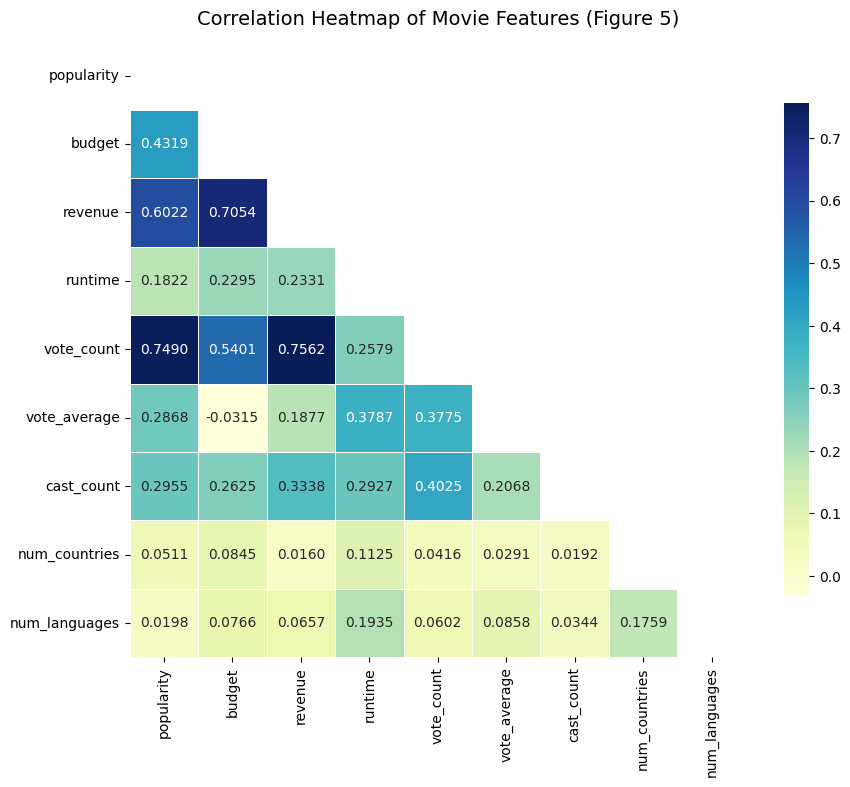

In [39]:
corr = no_null_merged_df[['popularity' , 'budget', 'revenue', 'runtime' , 'vote_count', 'vote_average', 'cast_count', 'num_countries', 'num_languages']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".4f", cmap="YlGnBu",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap of Movie Features (Figure 5)", fontsize=14, pad=12)
plt.show()

There are some key observation we can infer here, that there are some pair of attributes, which seems highly correlated (pearson correlation > 0.5), listed below in ascending order. 

1. Vote count vs Revenue <b>(0.7562)</b>
2. Vote count vs Popularity <b>(0.7490)</b>
3. Budget vs Revenue <b>(0.7054)</b>
4. Popularity vs Revenue <b>(0.6022)</b>
5. Vote count vs budget <b>(0.5401)</b>

### 4. Scatter Plots for Highly Correlated Pairs of attributes:

From the above heatmap we can notice there are some pair of variables seems highly correlated listed below
- Vote count vs Revenue
- Vote count vs Popularity
- Budget vs Revenue
- Popularity vs Revenue
- Vote count vs budget

##### Vote count vs Revenue

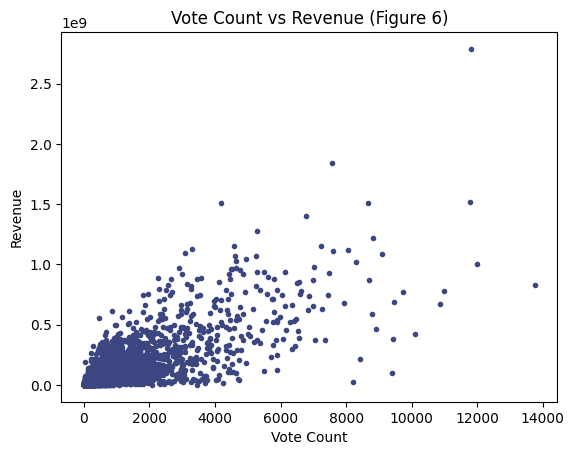

In [40]:
x = no_null_merged_df["vote_count"]
y = no_null_merged_df["revenue"]

plt.plot(x, y, '.', color='#3c4680')
plt.xlabel("Vote Count")
plt.ylabel("Revenue")
plt.title("Vote Count vs Revenue (Figure 6)");

##### Vote count vs Popularity

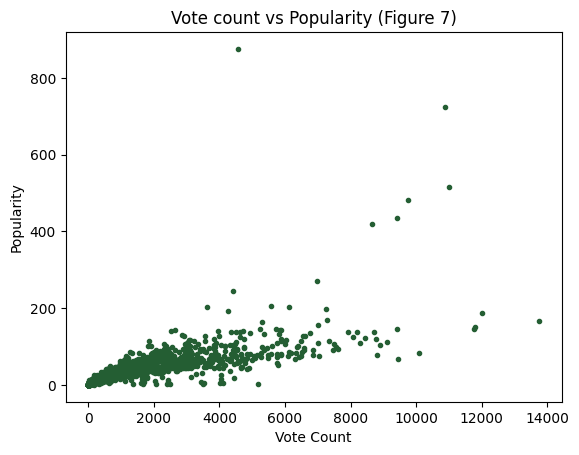

In [41]:
x = no_null_merged_df["vote_count"]
y = no_null_merged_df["popularity"]

plt.plot(x, y, '.', color='#245e33')
plt.xlabel("Vote Count")
plt.ylabel("Popularity")
plt.title("Vote count vs Popularity (Figure 7)");

##### Budget vs Revenue

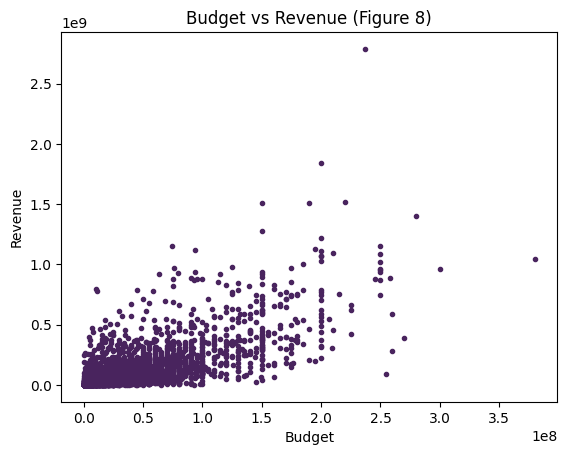

In [42]:
x = no_null_merged_df["budget"]
y = no_null_merged_df["revenue"]

plt.plot(x, y, '.', color='#49245e')
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue (Figure 8)");

##### Popularity vs Revenue

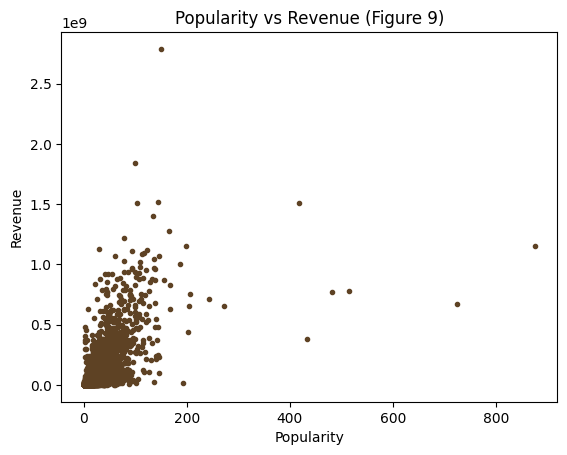

In [43]:
x = no_null_merged_df["popularity"]
y = no_null_merged_df["revenue"]

plt.plot(x, y, '.', color='#5e4224')
plt.xlabel("Popularity")
plt.ylabel("Revenue")
plt.title("Popularity vs Revenue (Figure 9)");

Vote count vs budget

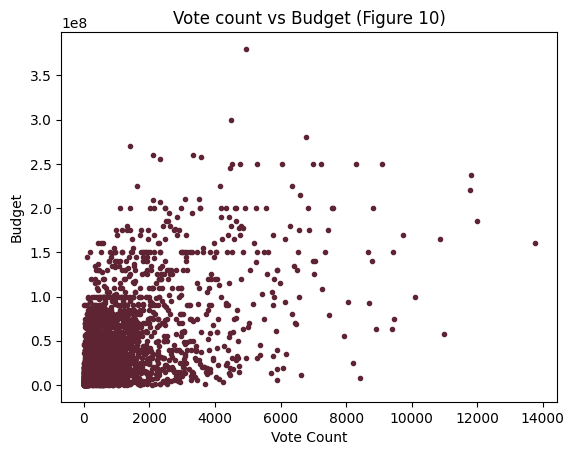

In [44]:
x = no_null_merged_df["vote_count"]
y = no_null_merged_df["budget"]

plt.plot(x, y, '.', color='#5e2433')
plt.xlabel("Vote Count")
plt.ylabel("Budget")
plt.title("Vote count vs Budget (Figure 10)");

Conclusion of these scatter plots:
    These plots are seeming to have pearson correlation, which is based on the assupmtion that the data is homoscedastic, But after visualisation we can clearly see to that its heteroscedastic. So we cannot coclude the correlation confidentatly.

### 5. Audience Ratings vs Runtime vs Cast Count plot

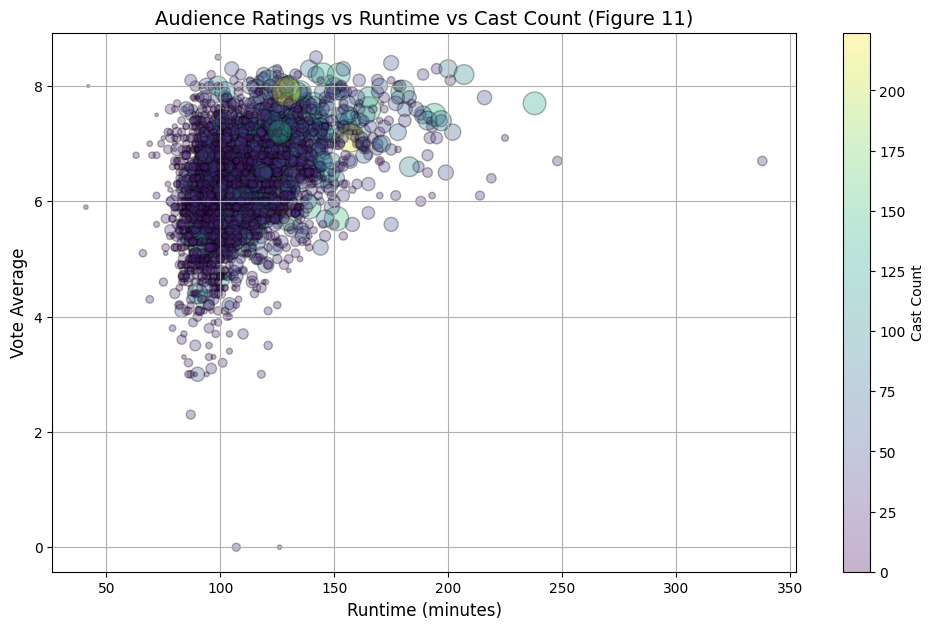

In [45]:
plt.figure(figsize=(12,7))

# Scatter: x = runtime, y = vote_average, size = cast_count, color = cast_count (or vote_average)
scatter = plt.scatter(
    no_null_merged_df["runtime"],
    no_null_merged_df["vote_average"],
    c=no_null_merged_df["cast_count"],
    s=no_null_merged_df["cast_count"]*2,
    cmap="viridis",
    alpha=0.3,
    edgecolor="k"
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Cast Count")

plt.title("Audience Ratings vs Runtime vs Cast Count (Figure 11)", fontsize=14)
plt.xlabel("Runtime (minutes)", fontsize=12)
plt.ylabel("Vote Average", fontsize=12)
plt.grid(True)
plt.show()


# <b>Hypothesis Testing</b>

##### <b>1. More Popular the movie, More people hype the movie to make others watch the movie, which increases vote count.</b>
From the Heatmap, its clearly visible that, there seems a high correlation (0.749) between vote count and popularity, but from the scatter plots we can see to that, that the data is heteroscedastic. thus we can only tell that it might be partially valid

Thus, the hypothesis is partially valid.


##### <b>2. Higher budgets lead to higher revenues and greater popularity.</b>
From the same Heatmap again, we can see that, there is a high correlation (0.7054) between, budget and revenue,but from the scatter plots we can see to that, that the data is highly heteroscedastic. And also there is very less correlation between popularity and budget thus we can tell that the hypothesis is not valid.

Thus, the hypothesis is not valid.

##### <b>3. Movies with larger casts and longer runtimes tend to get better audience ratings.</b>
From the Figure we can see that the hypothesis is Partially valid, but not strongly supported. there are only larger bubbles (high cast count), on higher values of Runtime as well as higher values of Vote Average (Rating), but it also overlaps with smaller circle as well on other parts of the co-ordinate space as well, so we cant make any strong conclusions here.

In [46]:
merged_df.to_csv("movies_cleaned.csv", index=False)